# Python warmup — before the first recitation

**CPSY 1291 · Computational Cognitive Science · Brown University**

This notebook is **optional and ungraded**, but highly recommended. It exists so
that you can walk into the first recitation already comfortable with the basics:
running notebook cells, core Python, and enough numpy to read and write the kind
of code the assignments use. If your intro programming course was in Java,
Racket, MATLAB, or anything other than Python, this is for you. If you already
use numpy regularly, skim the section headers and skip ahead — nothing here
will be new to you.

Plan on 60 to 90 minutes, self-paced. Work top to bottom.

**How the exercises work.** Each section ends with one or two small exercises.
The exercise cell comes pre-filled with one possible answer so the notebook
runs cleanly end to end — but you will learn far more if you **delete the
sample answer and write your own** before looking at it. A check cell follows
each exercise: run it, and it will either congratulate you or tell you what to
fix. You cannot break anything. If a check fails, edit your answer and run
both cells again.

## 1. Running a notebook

A notebook is a sequence of cells. Text cells (like this one) explain; code
cells run Python. To run a cell, click it and press **Shift+Enter** — the
result appears just below, and the cursor moves to the next cell.

One thing trips up nearly everyone at first: **cells share a single Python
session, and what matters is the order you *ran* them in, not the order they
appear on the page.** If you run a cell that defines a variable, then edit an
earlier cell and re-run it, the later definition is still in memory. This is
convenient right up until it silently lies to you.

Try it: run the next two cells in order.

In [1]:
# Run me first (Shift+Enter).
message = "notebooks run cells in the order you execute them"

In [2]:
# Run me second. This cell only works because the one above ran first
# and left `message` in memory.
print(message)

notebooks run cells in the order you execute them


**The habit that saves you:** when a notebook starts behaving strangely, or
before you submit anything, use **Runtime → Restart session and run all**
(in Colab; in Jupyter it is Kernel → Restart & Run All). That wipes the memory
and re-runs every cell top to bottom, which is the only honest test that your
notebook actually works in the order it is written. We will ask you to do this
before submitting every assignment, so make it a reflex now.

## 2. Python basics: variables, lists, dicts, loops, functions

A quick tour of the Python you will use constantly. If this section feels
slow, jump to section 3 — numpy is where this course really lives.

**Variables and f-strings.** Python variables need no type declarations. To
build a string that includes a value, put an `f` before the quote and the
expression in braces — this is called an f-string, and you will see it in
every assignment.

In [3]:
n_neurons = 12
region = "V1"

# An f-string substitutes the value of whatever is inside the braces.
print(f"We recorded {n_neurons} neurons in {region}.")
print(f"Twice as many would be {2 * n_neurons}.")

We recorded 12 neurons in V1.
Twice as many would be 24.


**Lists** hold ordered sequences of anything. Indexing starts at **0**, and
negative indices count from the end.

In [4]:
rates = [4.1, 0.5, 7.2, 3.3]

print(rates[0])      # first element
print(rates[-1])     # last element
print(len(rates))    # how many elements

rates.append(9.0)    # add one to the end
print(rates)

4.1
3.3
4
[4.1, 0.5, 7.2, 3.3, 9.0]


**Dictionaries** map keys to values — good for labeled data, like a rate per
condition.

In [5]:
mean_rate = {"face": 12.4, "house": 3.1, "scrambled": 2.0}

print(mean_rate["face"])          # look up one value
mean_rate["noise"] = 1.5          # add a new entry

for condition, rate in mean_rate.items():
    print(f"{condition}: {rate} spikes/s")

12.4
face: 12.4 spikes/s
house: 3.1 spikes/s
scrambled: 2.0 spikes/s
noise: 1.5 spikes/s


**For-loops and functions.** A loop repeats a block once per element; a
function packages a computation so you can reuse it. Note that Python defines
blocks purely by **indentation** — no braces, no `end`.

In [6]:
def spikes_to_rate(n_spikes, duration_s):
    """Convert a spike count over a time window into a rate in spikes/s."""
    return n_spikes / duration_s

counts = [8, 1, 14, 6]
for c in counts:
    print(f"{c} spikes in 2 s  ->  {spikes_to_rate(c, 2.0)} spikes/s")

8 spikes in 2 s  ->  4.0 spikes/s
1 spikes in 2 s  ->  0.5 spikes/s
14 spikes in 2 s  ->  7.0 spikes/s
6 spikes in 2 s  ->  3.0 spikes/s


### Exercise 2.1 — your first function

Write a function `celsius_to_fahrenheit(c)` that converts a temperature from
Celsius to Fahrenheit. The formula is F = C × 9/5 + 32.

The cell below already contains one possible answer so the notebook runs.
Delete the body and write your own, then run the check cell.

In [7]:
def celsius_to_fahrenheit(c):
    return c * 9 / 5 + 32  # one possible answer — delete this line and write your own

In [8]:
# Check cell — run me, do not edit me.
assert callable(celsius_to_fahrenheit), (
    "Define a function named celsius_to_fahrenheit in the cell above, then run it.")
assert celsius_to_fahrenheit(0) == 32, (
    "celsius_to_fahrenheit(0) should be 32 — check the '+ 32' part of the formula.")
assert celsius_to_fahrenheit(100) == 212, (
    "celsius_to_fahrenheit(100) should be 212 — check the 9/5 part of the formula.")
assert celsius_to_fahrenheit(37) == 98.6, (
    "celsius_to_fahrenheit(37) should be 98.6 — body temperature. Close, but check the arithmetic.")
print("Exercise 2.1 passed. Nicely done.")

Exercise 2.1 passed. Nicely done.


### Exercise 2.2 — a loop that builds a list

Build a list called `squares` containing the squares of the numbers 0 through
9, so `squares` is `[0, 1, 4, ..., 81]`. Use a for-loop with `append`, or a
list comprehension if you know them — either is fine.

In [9]:
squares = []
for k in range(10):
    squares.append(k ** 2)  # one possible answer — delete this loop and write your own

In [10]:
# Check cell — run me, do not edit me.
assert isinstance(squares, list), "squares should be a list."
assert len(squares) == 10, (
    f"squares should have 10 elements (for 0 through 9); yours has {len(squares)}. "
    "Remember that range(10) stops at 9.")
assert squares == [k ** 2 for k in range(10)], (
    "The values are off. squares[3] should be 9 and squares[9] should be 81 — "
    "check that you are squaring (k ** 2), not doubling.")
print("Exercise 2.2 passed.")

Exercise 2.2 passed.


## 3. numpy arrays

Nearly all the data in this course — firing rates, images, network weights —
lives in **numpy arrays**. An array is like a list, with two crucial upgrades:

1. **Math works elementwise.** `array * 2` doubles every element. With a
   list, `list * 2` just glues two copies of the list together — watch it
   happen below.
2. **Speed.** Array operations run in compiled code, thousands of times faster
   than a Python loop. When we process images with millions of pixels, this is
   the difference between seconds and hours.

The universal convention is `import numpy as np` — you will see `np.` in
front of everything.

In [11]:
import numpy as np

rates_list = [4.0, 0.5, 7.0, 3.5]
rates = np.array(rates_list)

print("list * 2: ", rates_list * 2)   # concatenation — almost never what you want
print("array * 2:", rates * 2)        # elementwise — what you want
print("array + 1:", rates + 1)        # also elementwise

list * 2:  [4.0, 0.5, 7.0, 3.5, 4.0, 0.5, 7.0, 3.5]
array * 2: [ 8.  1. 14.  7.]
array + 1: [5.  1.5 8.  4.5]


Every array has a **shape** (how many elements along each dimension) and a
**dtype** (the type of its elements — usually `float64` or `int64` here).
Checking `.shape` is the single most useful debugging move in this course:
most numpy bugs are shape bugs.

In [12]:
a = np.array([1.0, 2.0, 3.0])                    # 1-D: three numbers
M = np.array([[1, 2, 3],
              [4, 5, 6]])                        # 2-D: 2 rows, 3 columns

print("a.shape:", a.shape, "  a.dtype:", a.dtype)
print("M.shape:", M.shape, "  M.dtype:", M.dtype)

# Handy constructors you will meet again:
print(np.zeros(4))            # four zeros
print(np.arange(0, 10, 2))    # like range(): start, stop, step
print(np.linspace(0, 1, 5))   # 5 evenly spaced points from 0 to 1, inclusive

a.shape: (3,)   a.dtype: float64
M.shape: (2, 3)   M.dtype: int64
[0. 0. 0. 0.]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]


### Exercise 3.1 — from counts to rates, all at once

The list `spike_counts` below gives spike counts from five neurons, each
recorded over a **2-second** window. Convert it into a numpy array of firing
rates in spikes/s, called `rates_hz`. No loop needed — one line of array math.

In [13]:
spike_counts = [12, 0, 31, 8, 5]

rates_hz = np.array(spike_counts) / 2.0  # one possible answer — delete and write your own

In [14]:
# Check cell — run me, do not edit me.
assert isinstance(rates_hz, np.ndarray), (
    "rates_hz should be a numpy array — wrap the list in np.array(...) first.")
assert rates_hz.shape == (5,), (
    f"rates_hz should have shape (5,), one rate per neuron; yours is {rates_hz.shape}.")
assert np.allclose(rates_hz, [6.0, 0.0, 15.5, 4.0, 2.5]), (
    "The values are off. The first neuron fired 12 spikes in 2 s, so its rate is 6.0 — "
    "divide by the window length, 2.0.")
print("Exercise 3.1 passed. That one line replaced a whole loop.")

Exercise 3.1 passed. That one line replaced a whole loop.


## 4. Indexing and slicing

**1-D** arrays index just like lists: position `[i]`, slice `[start:stop]`
(the stop is *excluded*), step `[::step]`, negatives from the end.

In [15]:
x = np.arange(10) * 10          # [ 0 10 20 30 40 50 60 70 80 90]

print(x[0], x[-1])              # first, last
print(x[2:5])                   # positions 2, 3, 4 — stop is excluded
print(x[:3])                    # first three
print(x[::2])                   # every second element

0 90
[20 30 40]
[ 0 10 20]
[ 0 20 40 60 80]


**2-D** arrays take one index per dimension, `[row, column]` — rows first,
always. Throughout this course, our data matrices put **one thing per row**
(a neuron, a trial, a stimulus) and **one measurement per column**.

- `M[1, 2]` — the single entry at row 1, column 2
- `M[1]` or `M[1, :]` — all of row 1 (a 1-D array)
- `M[:, 2]` — all of column 2 (also a 1-D array; the bare `:` means
  "everything along this dimension")

In [16]:
# responses: 3 neurons (rows) x 4 stimuli (columns)
responses = np.array([[ 2.0,  8.0,  1.0,  0.5],
                      [ 5.0,  5.5,  6.0,  5.0],
                      [ 0.0, 12.0,  0.0,  0.0]])

print("one entry, row 0 col 1:", responses[0, 1])
print("row 2 (neuron 2):      ", responses[2])
print("column 1 (stimulus 1): ", responses[:, 1])
print("first two rows:\n", responses[:2])

one entry, row 0 col 1: 8.0
row 2 (neuron 2):       [ 0. 12.  0.  0.]
column 1 (stimulus 1):  [ 8.   5.5 12. ]
first two rows:
 [[2.  8.  1.  0.5]
 [5.  5.5 6.  5. ]]


### Exercise 4.1 — pull out a neuron and a stimulus

From the `responses` matrix above (3 neurons × 4 stimuli):

- put **neuron 1's responses to all stimuli** in `neuron1` (a 1-D array of 4 numbers), and
- put **every neuron's response to stimulus 3** in `stim3` (a 1-D array of 3 numbers).

Remember: rows are neurons, columns are stimuli.

In [17]:
neuron1 = responses[1]      # one possible answer — delete and write your own
stim3 = responses[:, 3]     # one possible answer — delete and write your own

In [18]:
# Check cell — run me, do not edit me.
assert neuron1.shape == (4,), (
    f"neuron1 should be 1-D with 4 entries (one per stimulus); yours has shape {neuron1.shape}. "
    "A neuron is a row: responses[i] grabs a whole row.")
assert np.allclose(neuron1, [5.0, 5.5, 6.0, 5.0]), (
    "neuron1 has the wrong values — you may have grabbed a column instead of a row, "
    "or the wrong row. Neuron 1 is the middle row.")
assert stim3.shape == (3,), (
    f"stim3 should be 1-D with 3 entries (one per neuron); yours has shape {stim3.shape}. "
    "A stimulus is a column: responses[:, j] grabs a whole column.")
assert np.allclose(stim3, [0.5, 5.0, 0.0]), (
    "stim3 has the wrong values — check that you took column 3 (the last one), "
    "with rows first: responses[:, 3].")
print("Exercise 4.1 passed. Rows first, columns second — always.")

Exercise 4.1 passed. Rows first, columns second — always.


## 5. Summing and averaging along an axis

`responses.mean()` averages *everything* into one number. Usually you want
something more specific: the mean per neuron, or the mean per stimulus. That
is what the `axis` argument does, and here is the picture in words:

> **The axis you name is the one that disappears.** `axis=0` collapses the
> rows, leaving one number per **column**. `axis=1` collapses the columns,
> leaving one number per **row**.

So with our neurons-by-stimuli matrix: `mean(axis=0)` averages over neurons
(one number per stimulus), and `mean(axis=1)` averages over stimuli (one
number per neuron). When in doubt, print the shape of the result — the
collapsed axis is the one that vanished.

One extra flag you will meet later: `keepdims=True` keeps the collapsed axis
around with size 1 (shape `(3, 1)` instead of `(3,)`), which matters when you
subtract the result back from the original matrix.

In [19]:
print("responses.shape:        ", responses.shape)      # (3, 4)

per_stimulus = responses.mean(axis=0)   # collapse rows -> one number per column
per_neuron   = responses.mean(axis=1)   # collapse columns -> one number per row

print("mean(axis=0):", per_stimulus, "  shape:", per_stimulus.shape)
print("mean(axis=1):", per_neuron,   "  shape:", per_neuron.shape)
print("mean(axis=1, keepdims=True) shape:", responses.mean(axis=1, keepdims=True).shape)

responses.shape:         (3, 4)
mean(axis=0): [2.33333333 8.5        2.33333333 1.83333333]   shape: (4,)
mean(axis=1): [2.875 5.375 3.   ]   shape: (3,)
mean(axis=1, keepdims=True) shape: (3, 1)


### Exercise 5.1 — total spikes per neuron

Using `responses` again, compute `total_per_neuron`: the **sum** of each
neuron's responses across all four stimuli. One number per neuron, so the
result should have shape `(3,)`. Which axis disappears?

In [20]:
total_per_neuron = responses.sum(axis=1)  # one possible answer — delete and write your own

In [21]:
# Check cell — run me, do not edit me.
assert total_per_neuron.shape == (3,), (
    f"total_per_neuron should have shape (3,) — one total per neuron; yours is "
    f"{total_per_neuron.shape}. You want one number per ROW, so the columns must "
    "collapse: that is axis=1.")
assert np.allclose(total_per_neuron, [11.5, 21.5, 12.0]), (
    "The shape is right but the values are off — check that you used sum, not mean.")
print("Exercise 5.1 passed. The axis you name is the one that disappears.")

Exercise 5.1 passed. The axis you name is the one that disappears.


## 6. Boolean masks: asking questions of your data

Comparing an array to a number gives back an array of `True`/`False` — a
**mask**. Masks are how you ask questions like "which responses were above
threshold?" without writing a loop.

In [22]:
r = np.array([2.0, 8.0, 1.0, 0.5, 5.0, 12.0])

mask = r > 4.0
print("mask:          ", mask)
print("values > 4:    ", r[mask])        # keep only where the mask is True
print("how many > 4:  ", mask.sum())     # True counts as 1, False as 0
print("fraction > 4:  ", mask.mean())    # so the mean of a mask is a fraction

mask:           [False  True False False  True  True]
values > 4:     [ 8.  5. 12.]
how many > 4:   3
fraction > 4:   0.5


That last line is a trick worth memorizing: **the mean of a boolean mask is
the fraction of entries that satisfy the condition.** It shows up constantly —
"what fraction of trials were correct" is one line.

To combine conditions, numpy uses `&` (and), `|` (or), `~` (not) — **not**
the words `and`/`or` — and **each condition needs its own parentheses**,
because `&` binds tighter than `>`.

In [23]:
in_range = (r > 1.0) & (r < 9.0)
print("between 1 and 9:", r[in_range])
print("NOT in range:   ", r[~in_range])

# Two classic mistakes, shown here commented out so the notebook still runs.
# Uncomment either line, run the cell, read the error, then re-comment it —
# you will meet both errors again, and it helps to have seen them on purpose.

# r > 1.0 & r < 9.0      # missing parentheses: '&' grabs '1.0 & r' first -> error
# (r > 1.0) and (r < 9.0)  # using 'and' on arrays ->
#     "ValueError: The truth value of an array with more than one element is
#      ambiguous" — numpy does not know if you mean 'all True' or 'any True'.
#      The fix is always the same: parentheses around each condition, joined by &.

between 1 and 9: [2. 8. 5.]
NOT in range:    [ 1.   0.5 12. ]


Masks also select **rows of a matrix**. If a mask has one entry per row,
`M[mask]` keeps just the rows where it is `True` — for example, only the
neurons whose average response clears some threshold.

In [24]:
active = responses.mean(axis=1) > 3.0     # one True/False per neuron
print("active mask:", active)
print("responses of active neurons only:\n", responses[active])

active mask: [False  True False]
responses of active neurons only:
 [[5.  5.5 6.  5. ]]


### Exercise 6.1 — fraction above threshold

The array `trial_rates` below holds firing rates from 20 trials. Compute
`frac_active`: the **fraction** of trials with a rate strictly greater than
5.0 spikes/s. One line, no loop — and remember what the mean of a mask gives
you.

In [25]:
trial_rates = np.array([3.1, 7.2, 5.0, 9.8, 1.4, 6.6, 4.2, 8.1, 0.9, 4.6,
                        2.7, 7.7, 6.1, 3.3, 4.9, 10.2, 5.6, 2.2, 6.8, 4.4])

frac_active = (trial_rates > 5.0).mean()  # one possible answer — delete and write your own

In [26]:
# Check cell — run me, do not edit me.
assert np.isscalar(frac_active) or getattr(frac_active, "shape", None) == (), (
    "frac_active should be a single number, not an array — take the .mean() of the mask.")
assert not (frac_active == 9), (
    "It looks like you counted the trials above threshold (9 of them) — "
    "the question asks for the FRACTION. mean() instead of sum().")
assert abs(frac_active - 0.45) < 1e-9, (
    "Expected 0.45 (9 of the 20 trials are above 5.0). Check the comparison: "
    "strictly greater than 5.0, so the trial at exactly 5.0 does not count.")
print("Exercise 6.1 passed. The mean of a mask is a fraction — keep that one.")

Exercise 6.1 passed. The mean of a mask is a fraction — keep that one.


## 7. A first plot

We use **matplotlib** for figures, imported by convention as `plt`. The
pattern below — compute your x and y arrays, `plt.plot`, then label
everything — covers most of the figures you will make this semester. A plot
without axis labels is unreadable a week later, including to you, so labels
and a title are part of the plot, not decoration.

Here is a classic from visual neuroscience: a **tuning curve**, a neuron's
firing rate as a function of stimulus orientation, with a bit of seeded
measurement noise added.

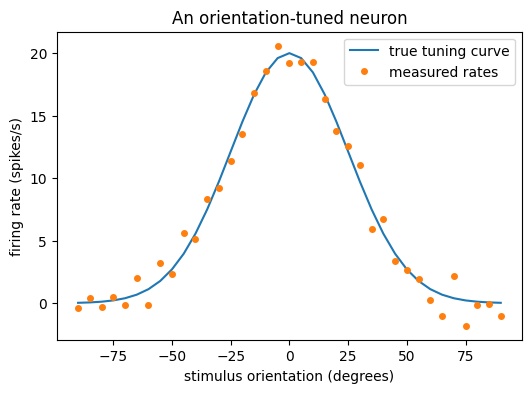

In [27]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(1291)                     # seeded, so everyone sees the same plot

orientation = np.linspace(-90, 90, 37)                # stimulus orientation, degrees
tuning = 20 * np.exp(-(orientation ** 2) / (2 * 25 ** 2))   # bell-shaped tuning curve
measured = tuning + rng.normal(0, 1.0, size=orientation.shape)  # noisy measurements

plt.figure(figsize=(6, 4))
plt.plot(orientation, tuning, label="true tuning curve")
plt.plot(orientation, measured, "o", markersize=4, label="measured rates")
plt.xlabel("stimulus orientation (degrees)")
plt.ylabel("firing rate (spikes/s)")
plt.title("An orientation-tuned neuron")
plt.legend()
plt.show()

### Exercise 7.1 — plot a sine wave

Make `x`: 100 evenly spaced points from 0 to 2π (`np.pi` is π, and
`np.linspace` is your friend). Make `y`: the sine of `x` (`np.sin`). Then plot
`y` against `x` with an x-label, a y-label, and a title of your choosing.

The check cell verifies `x` and `y`; the labels are on your honor.

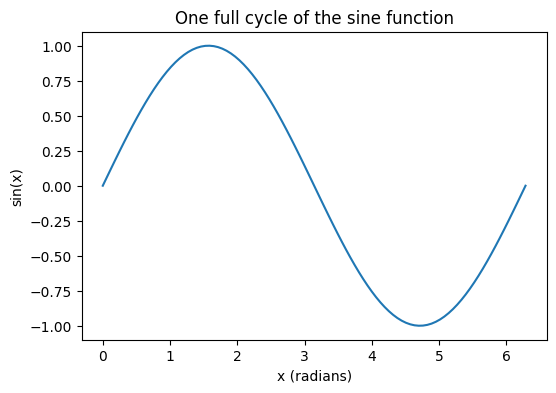

In [28]:
x = np.linspace(0, 2 * np.pi, 100)   # one possible answer — delete and write your own
y = np.sin(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.xlabel("x (radians)")
plt.ylabel("sin(x)")
plt.title("One full cycle of the sine function")
plt.show()

In [29]:
# Check cell — run me, do not edit me.
assert x.shape == (100,), (
    f"x should have exactly 100 points; yours has shape {x.shape}. "
    "np.linspace(start, stop, num) — the third argument is the count.")
assert abs(x[0] - 0) < 1e-9 and abs(x[-1] - 2 * np.pi) < 1e-9, (
    "x should run from 0 to 2*pi inclusive — check your start and stop values.")
assert y.shape == x.shape and np.allclose(y, np.sin(x)), (
    "y should be np.sin(x), evaluated on your x array.")
print("Exercise 7.1 passed. That is the last check — you are done.")

Exercise 7.1 passed. That is the last check — you are done.


## 8. Where this goes next

That is the warmup. You can now run cells in order, write a small function,
build arrays, slice rows and columns, collapse an axis, filter with a mask,
and make a labeled plot — which is genuinely most of the day-to-day numpy in
this course.

**Recitation 1 picks up exactly here** and adds the two tools this notebook
deliberately left out: **broadcasting** (how numpy combines arrays of
different shapes, and how to read the error message when it refuses) and
**fancy indexing** (indexing an array with another array of positions). Both
appear in Assignment 1, so if any section above felt shaky, recitation 1 is
where to bring your questions.

Recitation schedule and materials: *[link to the recitations page]*.

A reminder, since it bears repeating: this notebook is **optional and
ungraded**. It exists only so that the first weeks of the course are about
the ideas, not the syntax. If you worked through it, you are ready.